In [1]:
# notebook to plot the distribution of TF seqlet locations across promoters
# to replace old Figure 4D for revisions


In [1]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import pybedtools
import numpy as np

In [12]:
def plot_tss_dist_from_collapsed_pickem_kde(collapsed_df, promoters_bed_path, output_path, tf_list, colorPal='Greens_r', title=''):
    """
    Calculates and plots the TSS-relative positional distribution for the
    top N TFs using a pre-collapsed and classified DataFrame.

    Args:
        collapsed_df (pd.DataFrame): 
            DataFrame with merged intervals and columns 'representative_tf' 
            and 'activity_class'.
        promoters_bed_path (str): 
            Path to the promoter BED6 file (must include strand).
        output_path (str): 
            Path to save the output plot.
        top_n (int, optional): 
            The number of top TFs to plot for each class. Defaults to 10.
    """
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    
    # 1. Prepare DataFrames
    # Use pybedtools for the intersection
    promoters = pybedtools.BedTool(promoters_bed_path)
    
    # Convert the collapsed df into a BedTool object in memory
    collapsed_bed = pybedtools.BedTool.from_dataframe(collapsed_df)
    
    # 2. Intersect collapsed intervals with promoters
    intersection = collapsed_bed.intersect(promoters, wa=True, wb=True)

    # The output will have 6 (collapsed) + 6 (promoter) = 12 columns
    df_intersect = intersection.to_dataframe(names=[
        'merged_chrom', 'merged_start', 'merged_end', 'merged_name', 
        'rep_tf', 'activity_class',
        'promo_chrom', 'promo_start', 'promo_end', 'promo_name', 
        'promo_score', 'promo_strand'
    ])

    # 3. Calculate position relative to TSS using the CENTER of the MERGED interval
    merged_center = (df_intersect['merged_start'] + df_intersect['merged_end']) / 2
    df_intersect['tss_relative_pos'] = np.where(
        df_intersect['promo_strand'] == '+',
        merged_center - df_intersect['promo_start'],
        df_intersect['promo_end'] - merged_center
    )
    df_intersect.loc[:,'tss_rel_pos'] = df_intersect['tss_relative_pos'] - 250
    # 4. Filter for selected TFs
    plot_df_tfs = df_intersect[df_intersect['rep_tf'].isin(tf_list)]
    
    # 5. Create the two-panel plot
    print("Plotting distributions...")
    fig, axes = plt.subplots(1, 1, figsize=(5, 2.5), sharex=True, dpi=300)
    
    # Plot selected TF families
    sns.kdeplot(data=plot_df_tfs, x='tss_rel_pos', hue='rep_tf',
                palette=colorPal, linewidth=1, ax=axes, cut=0, bw_adjust=1)
    plt.vlines(x=-42,ymin=0,ymax=0.006, linestyle='dashed', alpha=0.5, linewidth=0.5, color='k')
    plt.vlines(x=-26,ymin=0,ymax=0.006, linestyle='dashed', alpha=0.5, linewidth=0.5, color='k')
    plt.title(title, loc='left')
    sns.despine()
    #axes[0].set_title(f'Top {top_n} Activator TFs', fontsize=14)
    #axes[0].set_ylabel('Density')
    #axes[0].legend(title='TF', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight')
    #plt.close()

    print(f"Final plot saved to: {output_path}")
    return df_intersect

In [3]:
def plot_tss_dist_from_collapsed_pickem(collapsed_df, promoters_bed_path, output_path, tf_list, colorPal='Greens_r', title=''):
    """
    Calculates and plots the TSS-relative positional distribution for the
    top N TFs using a pre-collapsed and classified DataFrame.

    Args:
        collapsed_df (pd.DataFrame): 
            DataFrame with merged intervals and columns 'representative_tf' 
            and 'activity_class'.
        promoters_bed_path (str): 
            Path to the promoter BED6 file (must include strand).
        output_path (str): 
            Path to save the output plot.
        top_n (int, optional): 
            The number of top TFs to plot for each class. Defaults to 10.
    """
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    
    # 1. Prepare DataFrames
    # Use pybedtools for the intersection
    promoters = pybedtools.BedTool(promoters_bed_path)
    
    # Convert the collapsed df into a BedTool object in memory
    collapsed_bed = pybedtools.BedTool.from_dataframe(collapsed_df)
    
    # 2. Intersect collapsed intervals with promoters
    intersection = collapsed_bed.intersect(promoters, wa=True, wb=True)

    # The output will have 6 (collapsed) + 6 (promoter) = 12 columns
    df_intersect = intersection.to_dataframe(names=[
        'merged_chrom', 'merged_start', 'merged_end', 'merged_name', 
        'rep_tf', 'activity_class',
        'promo_chrom', 'promo_start', 'promo_end', 'promo_name', 
        'promo_score', 'promo_strand'
    ])

    # 3. Calculate position relative to TSS using the CENTER of the MERGED interval
    merged_center = (df_intersect['merged_start'] + df_intersect['merged_end']) / 2
    df_intersect['tss_relative_pos'] = np.where(
        df_intersect['promo_strand'] == '+',
        merged_center - df_intersect['promo_start'],
        df_intersect['promo_end'] - merged_center
    )
    df_intersect.loc[:,'tss_rel_pos'] = df_intersect['tss_relative_pos'] - 250
    # 4. Filter for selected TFs
    plot_df_tfs = df_intersect[df_intersect['rep_tf'].isin(tf_list)]
    
    # 5. Create the two-panel plot
    print("Plotting distributions...")
    fig, axes = plt.subplots(1, 1, figsize=(5, 2.5), sharex=True, dpi=300)
    
    # Plot selected TF families
    sns.histplot(data=plot_df_tfs, x='tss_rel_pos', hue='rep_tf',
                 palette=colorPal, element='poly', fill=False, stat='count', kde=False, linewidth=0.75, ax=axes, binwidth=1)#, cut=0)
    plt.vlines(x=-42,ymin=0,ymax=50, linestyle='dashed', alpha=0.5, linewidth=0.5, color='k')
    plt.vlines(x=-26,ymin=0,ymax=50, linestyle='dashed', alpha=0.5, linewidth=0.5, color='k')
    plt.title(title, loc='left')
    sns.despine()
    #axes[0].set_title(f'Top {top_n} Activator TFs', fontsize=14)
    #axes[0].set_ylabel('Density')
    #axes[0].legend(title='TF', bbox_to_anchor=(1.01, 1), loc='upper left')
    #plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight')
    #plt.close()

    print(f"Final plot saved to: {output_path}")
    return plot_df_tfs

In [4]:
# open collapsed BED files
# mpac k562
mpac_k_repTFs = pd.read_csv('../processed_data/bed_files/mpac_k562_merged_collapsed_repTFs_112225.bed', sep = '\t', header = None)
# mpac hepg2
mpac_h_repTFs = pd.read_csv('../processed_data/bed_files/mpac_hepg2_merged_collapsed_repTFs_112225.bed', sep = '\t', header = None)
# mpac sknsh
mpac_s_repTFs = pd.read_csv('../processed_data/bed_files/mpac_sknsh_merged_collapsed_repTFs_112225.bed', sep = '\t', header = None)

In [5]:
# open vierstra clusters for collapsing on families instead of tfs
vierstra_motifs = pd.read_excel('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/motif_annotations.xlsx', sheet_name=[0,1])
# make a dictionary out of the clusterIDs and Names - this will be used to generate the final dictionary with the motif names
idName_dict = dict(zip(vierstra_motifs[0]['Cluster_ID'], vierstra_motifs[0]['Name']))
# open the second page and assign the Names to the individual motifs
vierstra_motifs[1].loc[:,'cluster_name'] = [idName_dict.get(i) for i in vierstra_motifs[1]['Cluster_ID']]
# make a dictionary that pulls the motif name as a key and returns the vierstra family as a value
vierstra_motif_dict = dict(zip(vierstra_motifs[1]['Motif'], vierstra_motifs[1]['cluster_name']))

In [6]:
def mpac_collapsed_pro (path2bed,
                        motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed.copy()#[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : filtered_bed[4],
                             'tf_family' : [motif_dict.get((i)) for i in filtered_bed[4]],
                             'activity_class' : filtered_bed[5]})
    return bed2plot

In [7]:
# open TF seqlets and add gene name and vierstra cluster for TF
# k562
mpac_k_collapsedTFs = mpac_collapsed_pro('../processed_data/bed_files/mpac_k562_merged_collapsed_repTFs_112225.bed', vierstra_motif_dict)
# hepg2
mpac_h_collapsedTFs = mpac_collapsed_pro('../processed_data/bed_files/mpac_hepg2_merged_collapsed_repTFs_112225.bed', vierstra_motif_dict)
# sknsh
mpac_s_collapsedTFs = mpac_collapsed_pro('../processed_data/bed_files/mpac_sknsh_merged_collapsed_repTFs_112225.bed', vierstra_motif_dict)

In [8]:
tf_colorPal = {
    'KLF/SP/2' : '#C99640',
    'NRF1' : '#97AB4E',
    'NFY' : '#5CB79E',
    'CREB/ATF/1' : '#88CCE9',
    'ETS/1' : '#59B157',
    'TATA' : '#E37D73'
}

Plotting distributions...


Final plot saved to: ../figures/K562_promoter_seqlet_counts.pdf


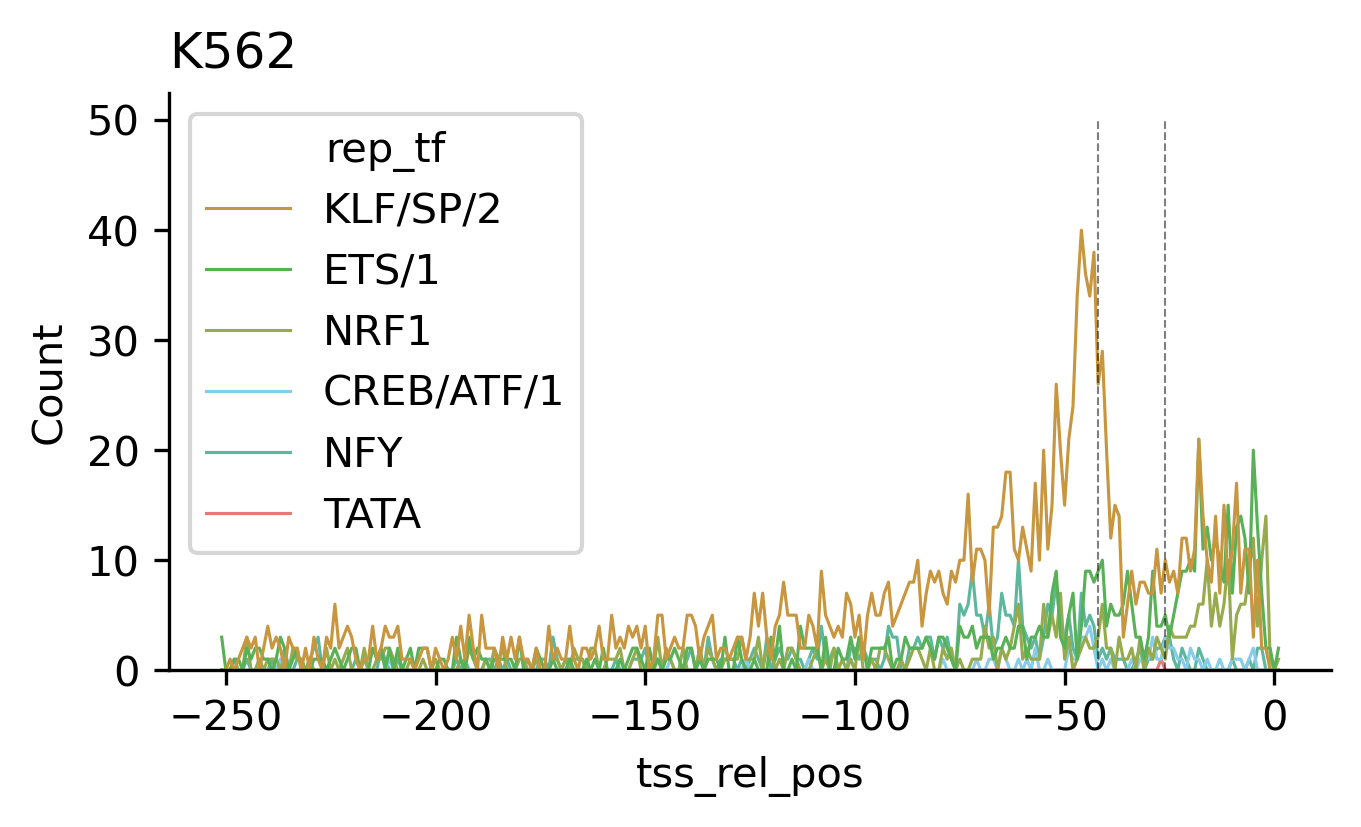

In [15]:
b = plot_tss_dist_from_collapsed_pickem(
    mpac_k_collapsedTFs,
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    '../figures/K562_promoter_seqlet_counts.pdf',
    ['KLF/SP/2', 'TATA', 'NRF1', 'NFY', 'ETS/1', 'CREB/ATF/1'],
    tf_colorPal,
    'K562')


Plotting distributions...
Final plot saved to: ../figures/HepG2_promoter_seqlet_counts.pdf


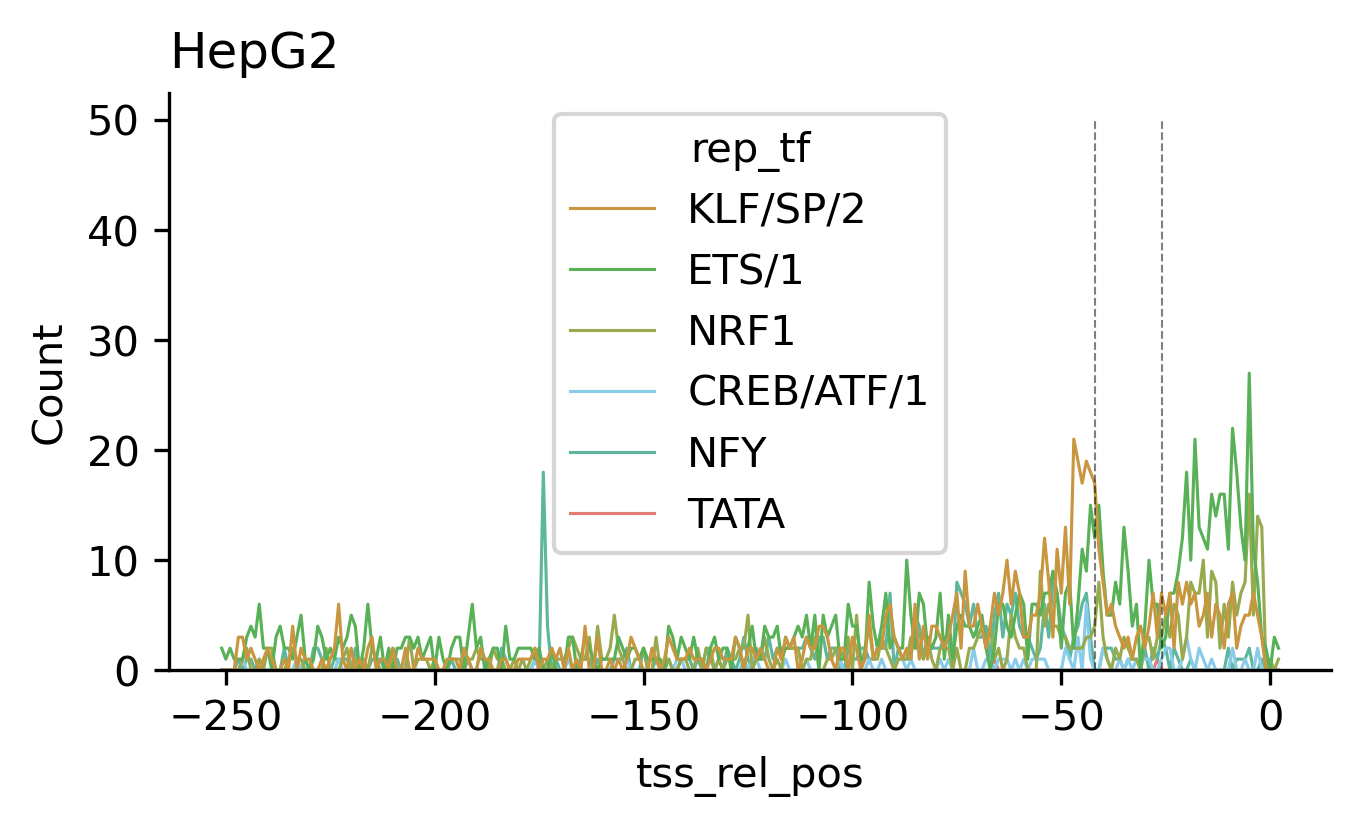

In [16]:
b = plot_tss_dist_from_collapsed_pickem(
    mpac_h_collapsedTFs,
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    '../figures/HepG2_promoter_seqlet_counts.pdf',
    ['KLF/SP/2', 'TATA', 'NRF1', 'NFY', 'ETS/1', 'CREB/ATF/1'],
    tf_colorPal,
    'HepG2')

Plotting distributions...
Final plot saved to: ../figures/SKNSH_promoter_seqlet_counts.pdf


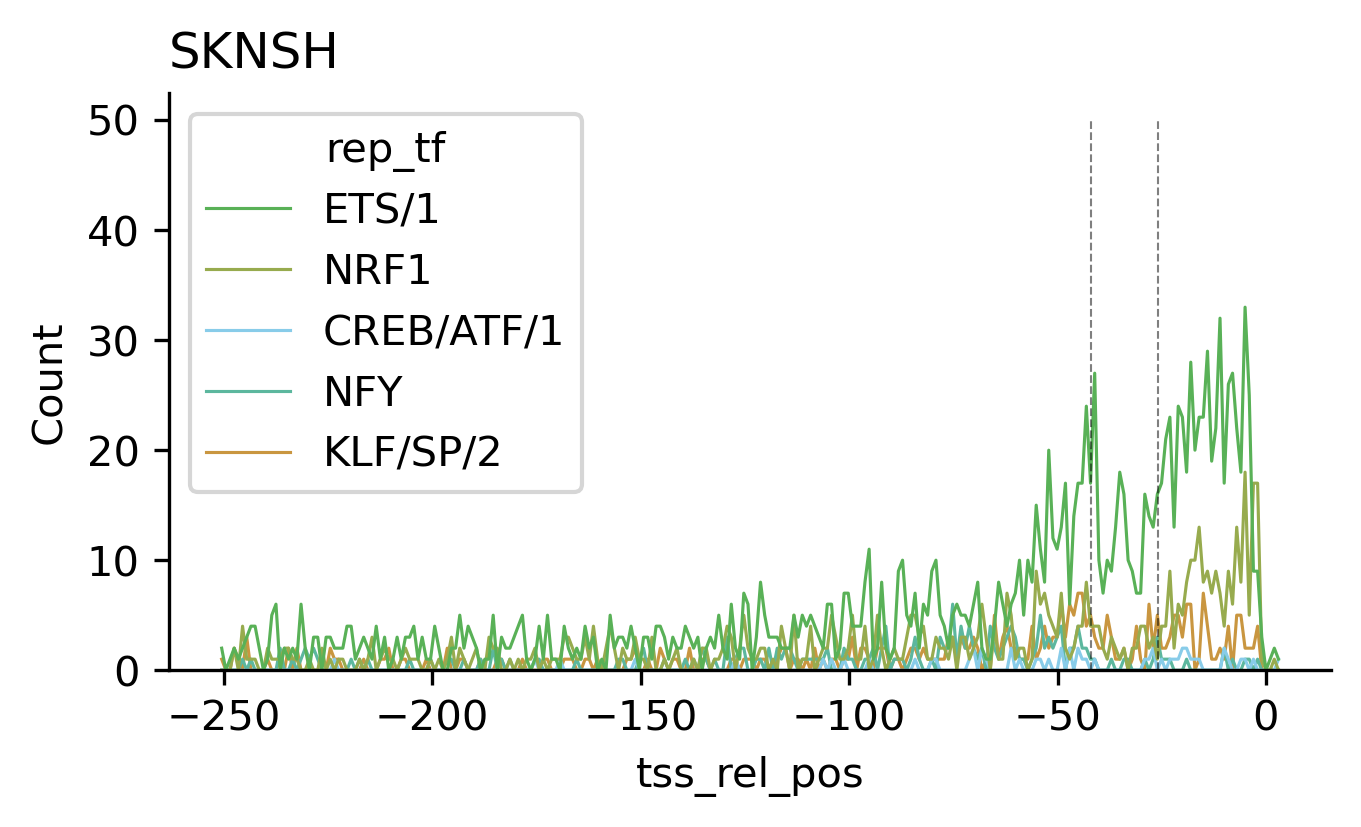

In [23]:
b = plot_tss_dist_from_collapsed_pickem(
    mpac_s_collapsedTFs,
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    '../figures/SKNSH_promoter_seqlet_counts.pdf',
    ['KLF/SP/2', 'TATA', 'NRF1', 'NFY', 'ETS/1', 'CREB/ATF/1'],
    tf_colorPal,
    'SKNSH')

Plotting distributions...
Final plot saved to: ../figures/All_promoter_seqlet_counts_drop_dupes.pdf


,merged_chrom,merged_start,merged_end,merged_name,rep_tf,activity_class,promo_chrom,promo_start,promo_end,promo_name,promo_score,promo_strand,tss_relative_pos,tss_rel_pos
2,chr1,966456,966462,SP1_HUMAN.H11MO.0.A,KLF/SP/2,Activator,chr1,966231,966481,ENSG00000187583.11_ENST00000379410.8_PLEKHN1,0,+,228.0,-22.0
5,chr1,1013437,1013443,SP1_HUMAN.H11MO.0.A,KLF/SP/2,Activator,chr1,1013246,1013496,ENSG00000187608.10_ENST00000649529.1_ISG15,0,+,194.0,-56.0
6,chr1,1116093,1116098,SP1_HUMAN.H11MO.0.A,KLF/SP/2,Activator,chr1,1116089,1116339,ENSG00000131591.18_ENST00000421241.7_C1orf159,0,-,243.5,-6.5
9,chr1,1308121,1308129,ELK1_HUMAN.H11MO.0.B,ETS/1,Activator,chr1,1307930,1308180,ENSG00000131584.19_ENST00000354700.10_ACAP3,0,-,55.0,-195.0
13,chr1,1399542,1399551,ELK4_HUMAN.H11MO.0.A,ETS/1,Activator,chr1,1399335,1399585,ENSG00000221978.13_ENST00000400809.8_CCNL2,0,-,38.5,-211.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24906,chr9,137205664,137205678,ELK1_HUMAN.H11MO.0.B,ETS/1,Activator,chr9,137205449,137205699,ENSG00000188566.15_ENST00000684003.1_NDOR1,0,+,222.0,-28.0
24907,chr9,137205664,137205678,ELK1_HUMAN.H11MO.0.B,ETS/1,Activator,chr9,137205648,137205898,ENSG00000187713.7_ENST00000343666.6_TMEM203,0,-,227.0,-23.0
24912,chr9,137423255,137423260,ELK4_HUMAN.H11MO.0.A,ETS/1,Activator,chr9,137423142,137423392,ENSG00000188747.9_ENST00000683555.1_NOXA1,0,+,115.5,-134.5
24913,chr9,137423255,137423260,ELK4_HUMAN.H11MO.0.A,ETS/1,Activator,chr9,137423162,137423412,ENSG00000187609.16_ENST00000340951.9_EXD3,0,-,154.5,-95.5


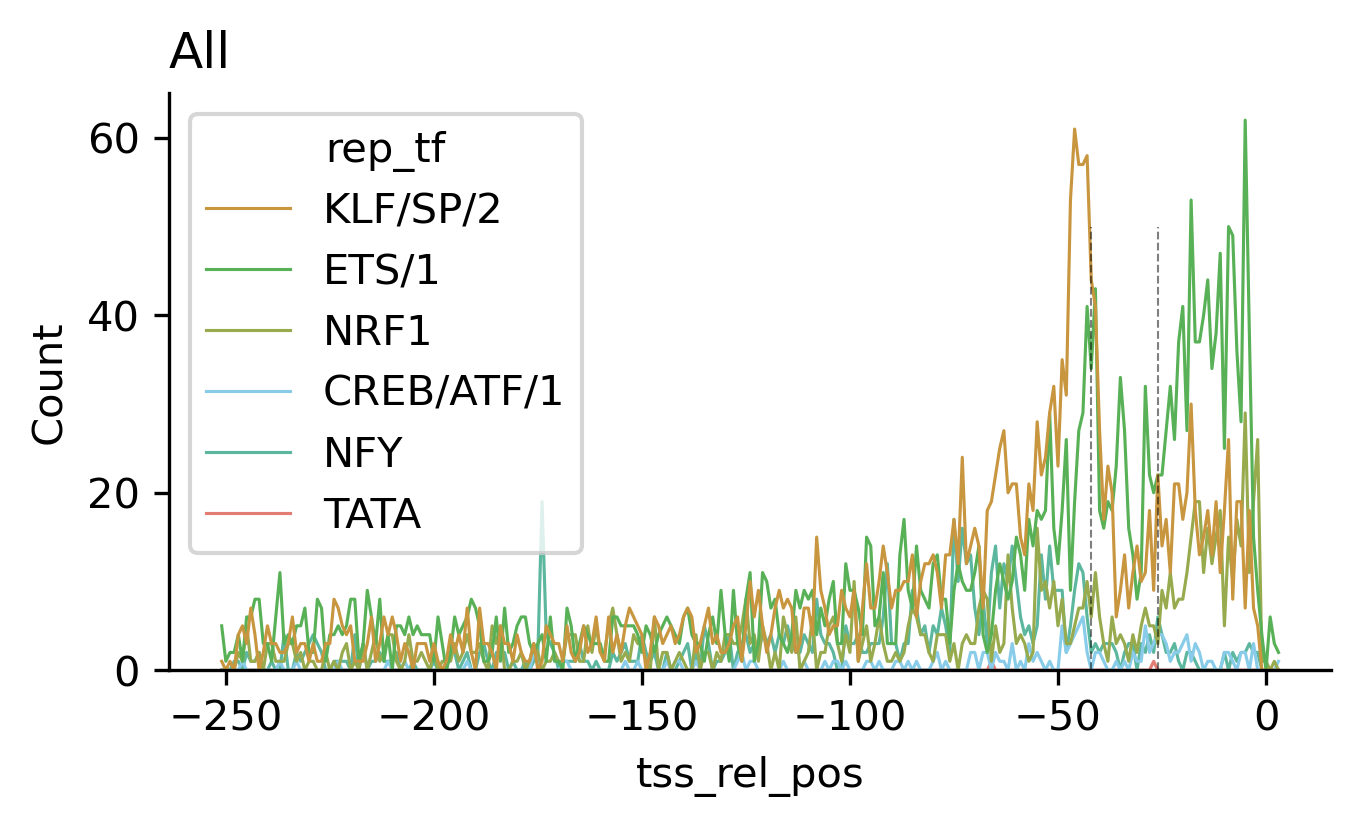

In [25]:
plot_tss_dist_from_collapsed_pickem(
    pd.concat([mpac_k_collapsedTFs, mpac_h_collapsedTFs, mpac_s_collapsedTFs]).drop_duplicates(),
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    '../figures/All_promoter_seqlet_counts_drop_dupes.pdf',
    ['KLF/SP/2', 'TATA', 'NRF1', 'NFY', 'ETS/1', 'CREB/ATF/1'],
    tf_colorPal,
    'All')

Plotting distributions...
Final plot saved to: ../figures/All_promoter_seqlet_counts_kde_binwidth_1.pdf


,merged_chrom,merged_start,merged_end,merged_name,rep_tf,activity_class,promo_chrom,promo_start,promo_end,promo_name,promo_score,promo_strand,tss_relative_pos,tss_rel_pos
0,chr1,966379,966387,SNAI1_HUMAN.H11MO.0.C,Ebox/CACCTG,Repressor,chr1,966231,966481,ENSG00000187583.11_ENST00000379410.8_PLEKHN1,0,+,152.0,-98.0
1,chr1,966432,966437,HIC1_HUMAN.H11MO.0.C,HIC/2,Repressor,chr1,966231,966481,ENSG00000187583.11_ENST00000379410.8_PLEKHN1,0,+,203.5,-46.5
2,chr1,966456,966462,SP1_HUMAN.H11MO.0.A,KLF/SP/2,Activator,chr1,966231,966481,ENSG00000187583.11_ENST00000379410.8_PLEKHN1,0,+,228.0,-22.0
3,chr1,1013389,1013394,NFAC4_HUMAN.H11MO.0.C,NFAT/1,Activator,chr1,1013246,1013496,ENSG00000187608.10_ENST00000649529.1_ISG15,0,+,145.5,-104.5
4,chr1,1013394,1013400,NFAC4_HUMAN.H11MO.0.C,NFAT/1,Activator,chr1,1013246,1013496,ENSG00000187608.10_ENST00000649529.1_ISG15,0,+,151.0,-99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29378,chr9,137459539,137459548,ZN680_HUMAN.H11MO.0.C,ZNF680,Repressor,chr9,137459334,137459584,ENSG00000165802.23_ENST00000371475.9_NSMF,0,-,40.5,-209.5
29379,chr9,137578926,137578934,ELK1_HUMAN.H11MO.0.B,ETS/1,Activator,chr9,137578925,137579175,ENSG00000148399.13_ENST00000277540.7_DPH7,0,-,245.0,-5.0
29380,chr9,137578948,137578955,ETV1_HUMAN.H11MO.0.A,ETS/1,Activator,chr9,137578925,137579175,ENSG00000148399.13_ENST00000277540.7_DPH7,0,-,223.5,-26.5
29381,chr9,137590716,137590723,E2F1_HUMAN.H11MO.0.A,E2F/2,Repressor,chr9,137590512,137590762,ENSG00000165724.6_ENST00000298585.3_ZMYND19,0,-,42.5,-207.5


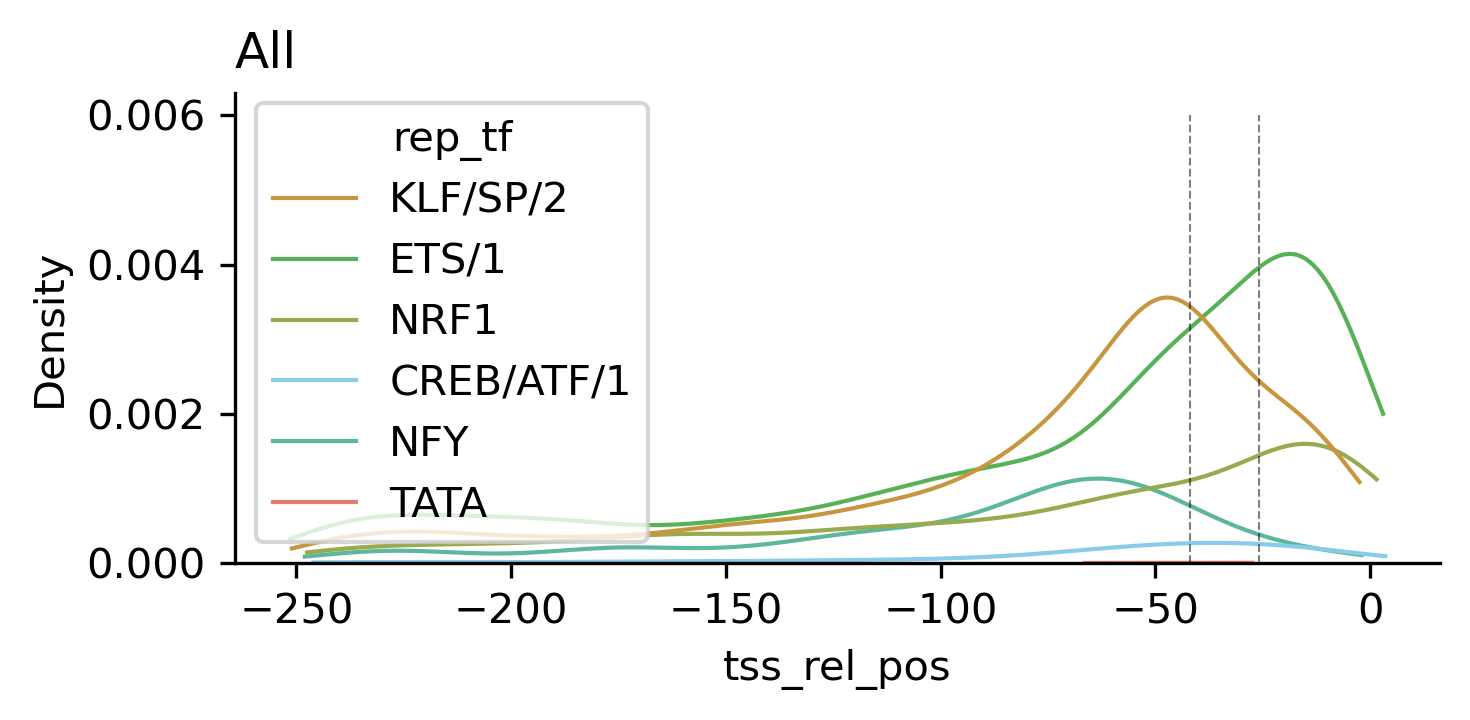

In [13]:
plot_tss_dist_from_collapsed_pickem_kde(
    pd.concat([mpac_k_collapsedTFs, mpac_h_collapsedTFs, mpac_s_collapsedTFs]),#.drop_duplicates(),
    '../raw_data/reformatted_bed_files/gencode.v44.protein.coding.250bp.promoters.autosomes.v2.full.ID.bed',
    '../figures/All_promoter_seqlet_counts_kde_binwidth_1.pdf',
    ['KLF/SP/2', 'TATA', 'NRF1', 'NFY', 'ETS/1', 'CREB/ATF/1'],
    tf_colorPal,
    'All')